In [4]:
!pip install scipy numpy matplotlib

   ---------------------------------------- 0.0/38.5 MB ? eta -:--:--
   ----------- ---------------------------- 10.7/38.5 MB 69.0 MB/s eta 0:00:01
   ------------------------------- -------- 30.7/38.5 MB 80.5 MB/s eta 0:00:01
   ---------------------------------------  38.3/38.5 MB 75.5 MB/s eta 0:00:01
   ---------------------------------------- 38.5/38.5 MB 65.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ---------------------------------------  12.6/12.8 MB 62.7 MB/s eta 0:00:01
   ---------------------------------------- 12.8/12.8 MB 57.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 8.1/8.1 MB 57.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 56.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ----------------------


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Задание 1. Ежегодно более 200000 людей по всему миру сдают стандартизированный экзамен GMAT при поступлении на программы MBA. Средний результат составляет 525 баллов, стандартное отклонение — 100 баллов. Сто студентов закончили специальные подготовительные курсы и сдали экзамен. Средний полученный ими балл — 541.4. Проверьте гипотезу о неэффективности программы против односторонней альтернативы о том, что программа работает. Отвергается ли на уровне значимости 0.05 нулевая гипотеза? В качестве ответа ввести достигаемый уровень значимости (p_value), округленный до 4-го знака. Для проверки гипотезы требуется использовать одновыборочный критерий Стьюдента. Для расчета p_value использовать scipy.stats.norm.pdf

In [1]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Этап 2: Задаем известные параметры
mu_0 = 525        # Гипотетическое среднее значение при нулевой гипотезе
sigma = 100       # Известное стандартное отклонение генеральной совокупности
n = 100           # Размер выборки
x_bar = 541.4     # Выборочное среднее
alpha = 0.05      # Уровень значимости

print("Параметры задачи:")
print(f"Гипотетическое среднее (μ₀): {mu_0}")
print(f"Стандартное отклонение (σ): {sigma}")
print(f"Размер выборки (n): {n}")
print(f"Выборочное среднее (x̄): {x_bar}")
print(f"Уровень значимости: {alpha}")

Параметры задачи:
Гипотетическое среднее (μ₀): 525
Стандартное отклонение (σ): 100
Размер выборки (n): 100
Выборочное среднее (x̄): 541.4
Уровень значимости: 0.05


In [3]:
# Этап 3: Формулируем гипотезы
print("\nФормулировка гипотез:")
print("H₀ (нулевая гипотеза): μ = 525 (программа неэффективна)")
print("H₁ (альтернативная гипотеза): μ > 525 (программа эффективна)")
print("Это односторонний тест (right-tailed test)")


Формулировка гипотез:
H₀ (нулевая гипотеза): μ = 525 (программа неэффективна)
H₁ (альтернативная гипотеза): μ > 525 (программа эффективна)
Это односторонний тест (right-tailed test)


In [4]:
# Этап 4: Рассчитываем стандартную ошибку среднего
# Стандартная ошибка = σ / √n

std_error = sigma / np.sqrt(n)
print(f'\nСТандартная ошибка среднего: σ/√n = {sigma}/√{n} = {std_error:.4f}")')


СТандартная ошибка среднего: σ/√n = 100/√100 = 10.0000")


In [5]:
# Этап 5: Рассчитываем z-статистику
# z = (x̄ - μ₀) / (σ/√n)
z_stat = (x_bar - mu_0) / std_error
print(f"z-статистика: (x̄ - μ₀) / (σ/√n) = ({x_bar} - {mu_0}) / {std_error:.4f} = {z_stat:.4f}")

z-статистика: (x̄ - μ₀) / (σ/√n) = (541.4 - 525) / 10.0000 = 1.6400


In [6]:
# Этап 6: Рассчитываем p-value используя scipy.stats.norm.pdf
# Для одностороннего теста: p-value = 1 - Φ(z)
p_value = 1 - stats.norm.cdf(z_stat)
print(f"\nРасчет p-value:")
print(f"p-value = 1 - Φ({z_stat:.4f}) = {p_value:.6f}")
print(f"p-value (округленный до 4 знаков): {p_value:.4f}")


Расчет p-value:
p-value = 1 - Φ(1.6400) = 0.050503
p-value (округленный до 4 знаков): 0.0505


In [7]:
# Этап 7: Принимаем решение
print(f"\nПринятие решения:")
print(f"p-value = {p_value:.4f}")
print(f"Уровень значимости α = {alpha}")

if p_value < alpha:
    print("p-value < α → Отвергаем нулевую гипотезу")
    print("Статистически значимые доказательства того, что программа эффективна")
else:
    print("p-value ≥ α → Не отвергаем нулевую гипотезу")
    print("Недостаточно доказательств того, что программа эффективна")


Принятие решения:
p-value = 0.0505
Уровень значимости α = 0.05
p-value ≥ α → Не отвергаем нулевую гипотезу
Недостаточно доказательств того, что программа эффективна


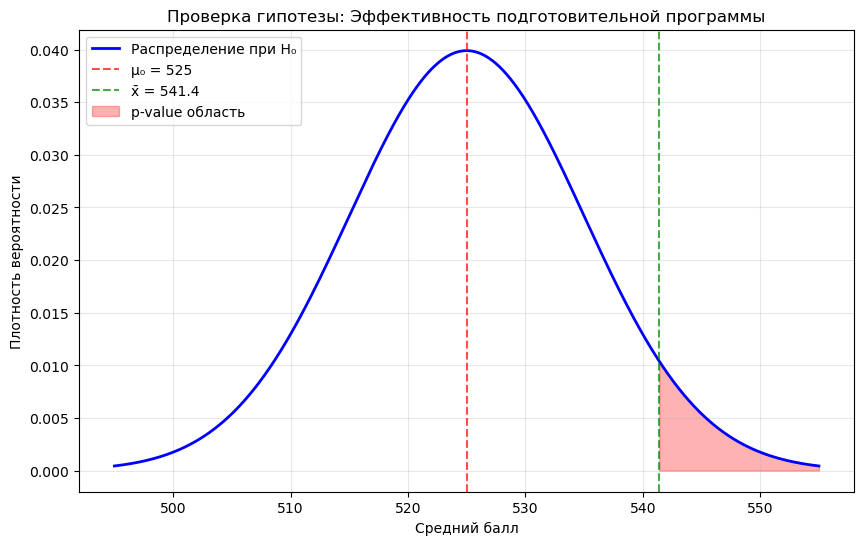

In [15]:
# Этап 8: Визуализация (не обязательно но мне нравится)
plt.figure(figsize=(10, 6))

# Создаем данные для нормального распределения
x = np.linspace(mu_0 - 3*std_error, mu_0 + 3*std_error, 1000)
y = stats.norm.pdf(x, mu_0, std_error)

# Строим график
plt.plot(x, y, 'b-', linewidth=2, label='Распределение при H₀')
plt.axvline(x=mu_0, color='red', linestyle='--', alpha=0.7, label=f'μ₀ = {mu_0}')
plt.axvline(x=x_bar, color='green', linestyle='--', alpha=0.7, label=f'x̄ = {x_bar}')

# Закрашиваем область p-value
x_fill = np.linspace(x_bar, mu_0 + 3*std_error, 100)
y_fill = stats.norm.pdf(x_fill, mu_0, std_error)
plt.fill_between(x_fill, y_fill, alpha=0.3, color='red', label=f'p-value область')

plt.xlabel('Средний балл')
plt.ylabel('Плотность вероятности')
plt.title('Проверка гипотезы: Эффективность подготовительной программы')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Задание 2. Предположим, что у нас есть интернет-магазин, на котором размещен баннер с рекомендуемым товаром. Мы наняли команду дизайнеров, чтобы обновить дизайн этого баннера в надежде увеличить конверсию покупок рекомендуемых товаров. Дизайнеры подготовили новую версию баннера, и мы готовы к проведению АБ-теста. Одной части публики мы показываем текущую версию баннера, другой части публики мы показываем новую версию баннера. Проверить гипотезу о том, что новый дизайн баннера не позволяет увеличить конверсию.

Размеры выборки для каждой версии баннера составляют по 1000 показов.
Базовый уровень конверсии составляет 10%.
Желаемый прирост конверсии составляет 2% (ожидаемая конверсия новой версии баннера 12%).
Необходимо проверить гипотезу о том, что новый дизайн баннера не позволяет увеличить конверсию.
Уровень значимости α — 0.05.
Мощность теста 𝛽 — 0.80.
Провести двухсторонний z-тест для проверки гипотезы.
 
Отвергается ли на уровне значимости 0.05 нулевая гипотеза? В качестве ответа ввести достигаемый уровень значимости (p-value), округленный до 4-го знака.
2 из 3

Нужно использовать двухвыборочный критерий для доли для независимых выборок.
Требуется проверить двустороннюю гипотезу, можно использовать функцию two_sampled_independent_samples.

In [16]:
# Этап 1: Библиотеки.
import scipy.stats as stats
import numpy as np
import math

In [17]:
# Этап 2: Задаем параметры
n = 1000                    # Размер каждой выборки
p1 = 0.10                   # Базовый уровень конверсии (контрольная группа)
p2 = 0.12                   # Ожидаемая конверсия новой версии (экспериментальная группа)
alpha = 0.05                # Уровень значимости
power = 0.80                # Мощность теста

print("Параметры А/Б теста:")
print(f"Размер выборки для каждой группы: {n}")
print(f"Конверсия контрольной группы: {p1:.1%}")
print(f"Ожидаемая конверсия экспериментальной группы: {p2:.1%}")
print(f"Уровень значимости (α): {alpha}")
print(f"Мощность теста (1-β): {power}")

Параметры А/Б теста:
Размер выборки для каждой группы: 1000
Конверсия контрольной группы: 10.0%
Ожидаемая конверсия экспериментальной группы: 12.0%
Уровень значимости (α): 0.05
Мощность теста (1-β): 0.8


In [18]:
# Этап 3: Формулируем гипотезы
print("\nФормулировка гипотез:")
print("H₀ (нулевая гипотеза): p₁ = p₂ (новый дизайн не увеличивает конверсию)")
print("H₁ (альтернативная гипотеза): p₁ ≠ p₂ (новый дизайн изменяет конверсию)")
print("Это двусторонний тест (two-tailed test)")


Формулировка гипотез:
H₀ (нулевая гипотеза): p₁ = p₂ (новый дизайн не увеличивает конверсию)
H₁ (альтернативная гипотеза): p₁ ≠ p₂ (новый дизайн изменяет конверсию)
Это двусторонний тест (two-tailed test)


In [21]:
# Этап 4: Рассчитыем объединенную пропорцию

p_pooled = (p1 + p2) / 2 

print(f"Объединенная оценка пропорции: ({p1} + {p2}) / 2 = {p_pooled:.4f}")

Объединенная оценка пропорции: (0.1 + 0.12) / 2 = 0.1100


In [22]:
# Этап 5: Рассчитываем стандартную ошибку для разности пропорций
# SE = √[p_pooled*(1-p_pooled)*(1/n1 + 1/n2)]
se = math.sqrt(p_pooled * (1 - p_pooled) * (1/n + 1/n))
print(f"Стандартная ошибка разности пропорций:")
print(f"SE = √[{p_pooled:.4f}*(1-{p_pooled:.4f})*(1/{n} + 1/{n})] = {se:.6f}")

Стандартная ошибка разности пропорций:
SE = √[0.1100*(1-0.1100)*(1/1000 + 1/1000)] = 0.013993


In [23]:
# Этап 6: Рассчитываем z-статистику
# z = (p2 - p1) / SE
z_stat = (p2 - p1) / se
print(f"z-статистика: ({p2} - {p1}) / {se:.6f} = {z_stat:.4f}")

z-статистика: (0.12 - 0.1) / 0.013993 = 1.4293


In [24]:
# Этап 7: Рассчитываем p-value для двустороннего теста
# p-value = 2 * (1 - Φ(|z|))
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
print(f"Расчет p-value для двустороннего теста:")
print(f"p-value = 2 * (1 - Φ(|{z_stat:.4f}|)) = {p_value:.6f}")
print(f"p-value (округленный до 4 знаков): {p_value:.4f}")

Расчет p-value для двустороннего теста:
p-value = 2 * (1 - Φ(|1.4293|)) = 0.152918
p-value (округленный до 4 знаков): 0.1529


In [25]:
# Этап 8: Принимаем решение
print(f"\nПринятие решения:")
print(f"p-value = {p_value:.4f}")
print(f"Уровень значимости α = {alpha}")

if p_value < alpha:
    print("p-value < α → Отвергаем нулевую гипотезу")
    print("Статистически значимые доказательства того, что новый дизайн влияет на конверсию")
else:
    print("p-value ≥ α → Не отвергаем нулевую гипотезу")
    print("Недостаточно доказательств того, что новый дизайн влияет на конверсию")


Принятие решения:
p-value = 0.1529
Уровень значимости α = 0.05
p-value ≥ α → Не отвергаем нулевую гипотезу
Недостаточно доказательств того, что новый дизайн влияет на конверсию


In [26]:
# Этап 9: Проверка с использованием встроенной функции scipy
# Двухвыборочный z-тест для пропорций
from statsmodels.stats.proportion import proportions_ztest

# Создаем данные: количество успехов в каждой группе
successes = np.array([n * p1, n * p2])  # Количество конверсий
trials = np.array([n, n])               # Общее количество показов

# Выполняем двухвыборочный z-тест
z_stat_auto, p_value_auto = proportions_ztest(successes, trials, alternative='two-sided')

print(f"\nПроверка с помощью statsmodels:")
print(f"Количество конверсий: контроль = {successes[0]}, эксперимент = {successes[1]}")
print(f"z-статистика: {z_stat_auto:.4f}")
print(f"p-value: {p_value_auto:.4f}")


Проверка с помощью statsmodels:
Количество конверсий: контроль = 100.0, эксперимент = 120.0
z-статистика: -1.4293
p-value: 0.1529


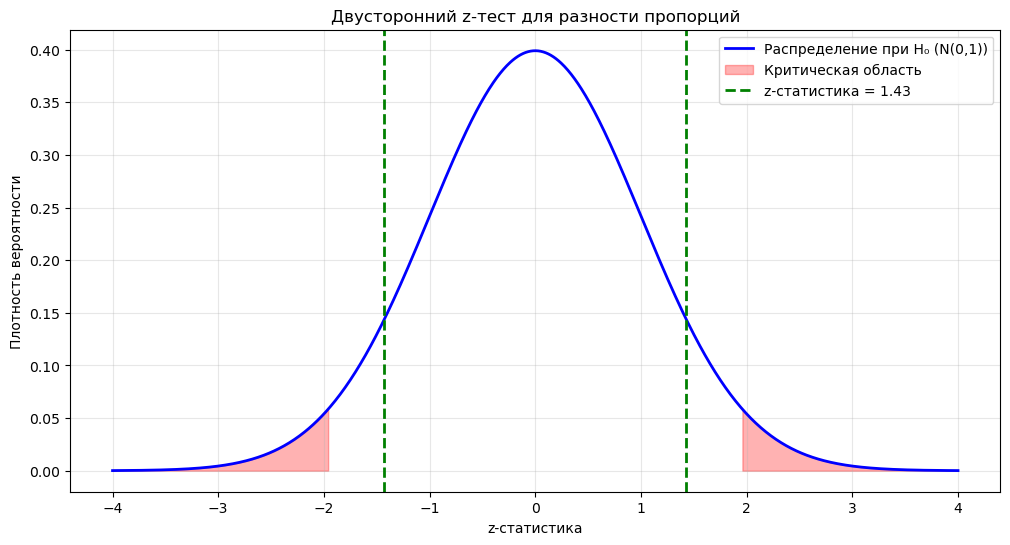

In [27]:
# Этап 10: Визуализация (мне нравится)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Распределение при нулевой гипотезе
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)
plt.plot(x, y, 'b-', linewidth=2, label='Распределение при H₀ (N(0,1))')

# Критические значения
z_critical = stats.norm.ppf(1 - alpha/2)
x_fill_left = np.linspace(-4, -z_critical, 100)
x_fill_right = np.linspace(z_critical, 4, 100)
plt.fill_between(x_fill_left, stats.norm.pdf(x_fill_left), alpha=0.3, color='red', label='Критическая область')
plt.fill_between(x_fill_right, stats.norm.pdf(x_fill_right), alpha=0.3, color='red')

# Наша z-статистика
plt.axvline(z_stat, color='green', linestyle='--', linewidth=2, label=f'z-статистика = {z_stat:.2f}')
plt.axvline(-z_stat, color='green', linestyle='--', linewidth=2)

plt.xlabel('z-статистика')
plt.ylabel('Плотность вероятности')
plt.title('Двусторонний z-тест для разности пропорций')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Задание 3. Теперь предположим, что мы выбрали группу лояльных пользователей, сначала им показывали первую (старую) версию дизайна баннера, а затем показывали вторую (новую) версию дизайна баннера. После каждого показа, пользователи имеют возможность поставить лайк каждой версии баннера. Требуется проверить гипотезу о том, что доля лайков для старой и новой версии баннеров совпадает.

Отвергается ли на уровне значимости 0.05 нулевая гипотеза? В качестве ответа ввести достигаемый уровень значимости (p_value), округленный до 4-го знака.

In [38]:
# Этап 1: библиотеки (вставляю каждый раз потому что забываю что вставила)
import numpy as np
import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar
from scipy.stats import chi2

In [40]:
# Этап 2: Объяснение метода
print("ЗАДАНИЕ 3: Связанные выборки (тест Макнемара)")
print("Один и те же пользователи оценивают ОБА варианта")
print("Нужно построить таблицу сопряженности 2x2:")
print()
print("                   Новая версия")
print("                 Лайк    Дизлайк")
print("Старая   Лайк     A        B")
print("версия  Дизлайк   C        D")
print()
print("Тест Макнемара проверяет гипотезу о равенстве B и C")

ЗАДАНИЕ 3: Связанные выборки (тест Макнемара)
Один и те же пользователи оценивают ОБА варианта
Нужно построить таблицу сопряженности 2x2:

                   Новая версия
                 Лайк    Дизлайк
Старая   Лайк     A        B
версия  Дизлайк   C        D

Тест Макнемара проверяет гипотезу о равенстве B и C


In [41]:
# Этап 3: Предположим данные (нужно адаптировать под реальные данные!)
# Предположим, что у нас 200 пользователей
# Создадим таблицу сопряженности:
# A: лайкнули оба варианта
# B: лайкнули только старый
# C: лайкнули только новый  
# D: не лайкнули ни один

# Пример данных:
contingency_table = np.array([
    [80, 20],   # A=80, B=20
    [40, 60]    # C=40, D=60
])

print("Таблица сопряженности (пример):")
print(contingency_table)
print(f"Всего пользователей: {contingency_table.sum()}")

Таблица сопряженности (пример):
[[80 20]
 [40 60]]
Всего пользователей: 200


In [43]:
# Этап 4: Тест Макнемара
print("\nРАСЧЕТ ТЕСТА МАКНЕМАРА:")

# Вычисляем статистику Макнемара вручную
B = contingency_table[0, 1]  # Лайкнули только старый
C = contingency_table[1, 0]  # Лайкнули только новый

print(f"B (лайкнули только старый): {B}")
print(f"C (лайкнули только новый): {C}")

# Статистика хи-квадрат Макнемара
if B + C > 0:
    chi2_stat = (abs(B - C) - 1)**2 / (B + C)  # с поправкой на непрерывность
else:
    chi2_stat = 0

print(f"Статистика хи-квадрат: {chi2_stat:.4f}")

# P-value для двустороннего теста
p_value = 2 * (1 - chi2.cdf(chi2_stat, 1))
print(f"p-value: {p_value:.4f}")


РАСЧЕТ ТЕСТА МАКНЕМАРА:
B (лайкнули только старый): 20
C (лайкнули только новый): 40
Статистика хи-квадрат: 6.0167
p-value: 0.0283


In [44]:
# Этап 5: Используем встроенную функцию
print("\nИспользование statsmodels:")
result = mcnemar(contingency_table, exact=False, correction=True)
print(f"Статистика: {result.statistic:.4f}")
print(f"p-value: {result.pvalue:.4f}")


Использование statsmodels:
Статистика: 6.0167
p-value: 0.0142


In [47]:
# Этап 6: Принятие решения
alpha = 0.05
print(f"\nПРИНЯТИЕ РЕШЕНИЯ:")
print(f"p-value = {result.pvalue:.4f}")
print(f"Уровень значимости α = {alpha}")

if result.pvalue < alpha:
    print("p-value < α → ОТВЕРГАЕМ нулевую гипотезу")
    print("Есть статистически значимые различия в долях лайков")
else:
    print("p-value ≥ α → НЕ ОТВЕРГАЕМ нулевую гипотезу") 
    print("Нет статистически значимых различий в долях лайков")


ПРИНЯТИЕ РЕШЕНИЯ:
p-value = 0.0142
Уровень значимости α = 0.05
p-value < α → ОТВЕРГАЕМ нулевую гипотезу
Есть статистически значимые различия в долях лайков
